[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/Time-Series-Analysis/blob/main/Quantlets/Ch_08/TSA_ch8_seminar/TSA_ch8_seminar.ipynb)

# Time Series Analysis — Seminar 8: Long memory and ARFIMA

*Seminar notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

- The seminar comes before Lecture 8; the slides give the definitions ("What you need today").
- [Solved] tasks: full solution here and in the slides; [Proposed] tasks: write your own code in the empty cell.
- The seminar is for practice and is not graded; the solutions of [Proposed] tasks are discussed in class.
- The first code cell installs the `arch` package if it is missing.

> Quantlet `TSA_ch8_seminar`: student version of the Seminar 8 notebook. Solved exercises (A1, A3, A5, B1, B3) are shown with code and output; the proposed exercises (A2, A4, A6, B2, B4, C1, C2) are not solved here (an empty code cell where they need code).

> The solutions are discussed in the seminar.

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [1]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/TSA/Chapter_8'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


Save your outputs to: /Users/danpele/Documents/Teaching/TSA - Serii de timp/repo/Quantlets/Ch_08/TSA_ch8_seminar


In [2]:
# The arch package (FIGARCH estimation) is not preinstalled in Google Colab: pip install arch
import importlib.util, subprocess, sys
if importlib.util.find_spec('arch') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'arch'])

In [3]:
import os
import re
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from scipy import optimize
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Chart style

- Transparent background, legend below the plot, course palette.

In [4]:
# Palette (RGB values of latex/preamble.tex)
MainBlue = '#1A3A6E'
IDAred = '#CD0000'
Forest = '#2E7D32'
Amber = '#B5853F'
Orange = '#E67E22'
Purple = '#8E44AD'
Teal = '#17A2B8'
Crimson = '#DC3545'
DarkText = '#1F2A44'          # text, axes and ticks (dark navy, not grey)

PALETTE = [MainBlue, IDAred, Forest, Amber, Purple, Orange, Teal, Crimson]
# fixed colours for the series used in several chapters
COL = {'sp500': MainBlue, 'bet': IDAred, 'bettr': Orange, 'dax': Teal, 'btc': Amber, 'eth': Crimson,
       'eurron': Forest, 'gold': Purple, 'vix': Crimson, 'stoxx50': Forest, 'ndx': Teal}


def apply():
    """Set the course style for matplotlib."""
    rc = plt.rcParams
    rc['figure.facecolor'] = 'none'
    rc['axes.facecolor'] = 'none'
    rc['savefig.facecolor'] = 'none'
    rc['savefig.transparent'] = True
    rc['axes.grid'] = False
    rc['font.family'] = 'sans-serif'
    rc['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
    # font sizes for slides (charts are 9-11 inches wide and shown at 8-14 cm)
    rc['font.size'] = 12
    rc['axes.labelsize'] = 13
    rc['axes.titlesize'] = 13
    rc['xtick.labelsize'] = 11.5
    rc['ytick.labelsize'] = 11.5
    rc['legend.fontsize'] = 11
    rc['axes.spines.top'] = False
    rc['axes.spines.right'] = False
    rc['axes.linewidth'] = 0.6
    rc['lines.linewidth'] = 1.4
    rc['legend.facecolor'] = 'none'
    rc['legend.framealpha'] = 0
    rc['legend.frameon'] = False
    for k in ('text.color', 'axes.labelcolor', 'axes.edgecolor', 'xtick.color', 'ytick.color', 'axes.titlecolor'):
        rc[k] = DarkText
    rc['axes.prop_cycle'] = mpl.cycler(color=PALETTE)


def legend_outside_bottom(ax, ncol=2, y=-0.22, **kw):
    """Place the legend outside the plot, bottom centre (for a figure with several axes, pass the last one
    or use fig.legend with the same arguments)."""
    return ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False, **kw)


def fig_legend_bottom(fig, handles=None, labels=None, ncol=3, y=-0.02):
    """One legend for a whole figure (several panels), below the panels."""
    if handles is None:
        handles, labels = [], []
        for ax in fig.axes:
            for h, l in zip(*ax.get_legend_handles_labels()):
                if l not in labels and not l.startswith('_'):
                    handles.append(h)
                    labels.append(l)
    return fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)


def _is_grey(c, tol=0.06):
    try:
        r, g, b = to_rgb(c)
    except ValueError:
        return False
    return max(r, g, b) - min(r, g, b) < tol and 0.25 < (r + g + b) / 3 < 0.95


def check_no_grey(fig):
    """House rule: no grey series and no grey text. Raises ValueError listing the offending elements."""
    bad = []
    for ax in fig.axes:
        for ln in ax.get_lines():
            if not ln.get_label().startswith('_') and _is_grey(ln.get_color()):
                bad.append(f'line {ln.get_label()!r}')
        for coll in ax.collections:
            fc = coll.get_facecolor()
            if len(fc) and coll.get_label() and not coll.get_label().startswith('_') and _is_grey(fc[0][:3]):
                bad.append(f'series {coll.get_label()!r}')
        for t in ax.texts + [ax.title, ax.xaxis.label, ax.yaxis.label]:
            if t.get_text() and _is_grey(t.get_color()):
                bad.append(f'text {t.get_text()[:30]!r}')
    if bad:
        raise ValueError('grey elements: ' + ', '.join(bad))


def save_fig(name, out_dir=None, show=True):
    """Save the figure as transparent PDF and PNG (OUT_DIR if defined, else the current folder), then show it."""
    d = out_dir or globals().get('OUT_DIR', '.')
    plt.savefig(os.path.join(d, f'{name}.pdf'), bbox_inches='tight', transparent=True)
    plt.savefig(os.path.join(d, f'{name}.png'), bbox_inches='tight', transparent=True, dpi=180)
    if show:
        plt.show()
    plt.close()


apply()
# the chapter scripts call the style as st.<name> (import tsa_style as st): the same names here
import types
st = types.SimpleNamespace(COL=COL, PALETTE=PALETTE, MainBlue=MainBlue, IDAred=IDAred, Forest=Forest, Amber=Amber,
                           Orange=Orange, Purple=Purple, Teal=Teal, Crimson=Crimson, DarkText=DarkText, apply=apply, legend_outside_bottom=legend_outside_bottom,
                           fig_legend_bottom=fig_legend_bottom, save_fig=save_fig, check_no_grey=check_no_grey)

## Data

- Daily market data from EODHD, saved in `data/market` of the TSA repository; EUR/RON is the official BNR reference rate.
- Macroeconomic series: FRED (St. Louis Fed), Eurostat and the classic data sets of statsmodels.
- Returns in %: $r_t = 100(\ln P_t - \ln P_{t-1})$; each series on its own calendar.

In [5]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/Time-Series-Analysis/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')
END = '2026-09-18'          # last day of the saved data

# name -> (symbol, label, group, field, default start)
SERIES = {
    # equity indices
    'sp500':    ('GSPC.INDX',     'S&P 500',               'Equity', 'close', '2000-01-01'),
    'ndx':      ('NDX.INDX',      'Nasdaq 100',            'Equity', 'close', '2000-01-01'),
    'dax':      ('GDAXI.INDX',    'DAX',                   'Equity', 'close', '2000-01-01'),
    'stoxx50':  ('STOXX50E.INDX', 'Euro Stoxx 50',         'Equity', 'close', '2000-01-01'),
    'nikkei':   ('N225.INDX',     'Nikkei 225',            'Equity', 'close', '2000-01-01'),
    'bet':      ('BET',           'BET',                   'Equity', 'close', '2000-01-01'),
    'bettr':    ('BETTR.INDX',    'BET-TR',                'Equity', 'close', '2014-09-23'),
    'betxt':    ('BETXT.INDX',    'BET-XT',                'Equity', 'close', '2011-08-12'),
    'betfi':    ('BETFI.INDX',    'BET-FI',                'Equity', 'close', '2012-01-25'),
    'wig20':    ('WIG20.INDX',    'WIG20',                 'Equity', 'close', '2000-01-01'),
    'bux':      ('BUX.INDX',      'BUX',                   'Equity', 'close', '2000-01-01'),
    'px':       ('PX.INDX',       'PX',                    'Equity', 'close', '2000-01-01'),
    'vix':      ('VIX.INDX',      'VIX',                   'Volatility', 'close', '2000-01-01'),
    # ETFs (adjusted close)
    'spy':      ('SPY.US',        'SPY',                   'ETF', 'adjusted_close', '2000-01-01'),
    'tlt':      ('TLT.US',        'TLT (US Treasuries 20y+)', 'ETF', 'adjusted_close', '2002-07-30'),
    'gld':      ('GLD.US',        'GLD (gold ETF)',        'ETF', 'adjusted_close', '2004-11-18'),
    'tvbetetf': ('TVBETETF.RO',   'TVBETETF',              'ETF', 'adjusted_close', '2015-06-12'),
    # Bucharest Stock Exchange (adjusted close)
    'tlv':      ('TLV.RO',        'Banca Transilvania',    'Stock', 'adjusted_close', '2000-01-01'),
    'snp':      ('SNP.RO',        'OMV Petrom',            'Stock', 'adjusted_close', '2001-09-04'),
    'brd':      ('BRD.RO',        'BRD',                   'Stock', 'adjusted_close', '2001-01-16'),
    'tgn':      ('TGN.RO',        'Transgaz',              'Stock', 'adjusted_close', '2008-01-25'),
    'sng':      ('SNG.RO',        'Romgaz',                'Stock', 'adjusted_close', '2013-11-12'),
    'snn':      ('SNN.RO',        'Nuclearelectrica',      'Stock', 'adjusted_close', '2013-11-04'),
    'h2o':      ('H2O.RO',        'Hidroelectrica',        'Stock', 'adjusted_close', '2023-07-12'),
    # US stocks (adjusted close)
    'aapl':     ('AAPL.US',       'Apple',                 'Stock', 'adjusted_close', '2000-01-01'),
    'msft':     ('MSFT.US',       'Microsoft',             'Stock', 'adjusted_close', '2000-01-01'),
    'nvda':     ('NVDA.US',       'NVIDIA',                'Stock', 'adjusted_close', '2000-01-01'),
    'jpm':      ('JPM.US',        'JPMorgan Chase',        'Stock', 'adjusted_close', '2000-01-01'),
    # crypto (close, 7 days a week)
    'btc':      ('BTC-USD.CC',    'Bitcoin',               'Crypto', 'close', '2014-09-17'),
    'eth':      ('ETH-USD.CC',    'Ethereum',              'Crypto', 'close', '2015-08-07'),
    'sol':      ('SOL-USD.CC',    'Solana',                'Crypto', 'close', '2020-04-11'),
    'usdt':     ('USDT-USD.CC',   'Tether (USDT)',         'Crypto', 'close', '2015-02-26'),
    # FX and commodities
    'eurron':   ('REF:EUR',       'EUR/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'usdron':   ('REF:USD',       'USD/RON (BNR reference)', 'FX', 'close', '2005-07-01'),
    'eurron_eodhd': ('EURRON.FOREX', 'EUR/RON (EODHD)',    'FX', 'close', '2005-07-01'),
    'eurusd':   ('EURUSD.FOREX',  'EUR/USD',               'FX', 'close', '2002-05-06'),
    'gold':     ('XAUUSD.FOREX',  'Gold (XAU/USD)',        'Commodity', 'close', '2000-01-01'),
    # government bond yields (close, % p.a.)
    'us10y':    ('US10Y.GBOND',   'US 10Y yield',          'Yield', 'close', '2000-01-01'),
    'de10y':    ('DE10Y.GBOND',   'Germany 10Y yield',     'Yield', 'close', '2007-03-28'),
    'ro10y':    ('RO10Y.GBOND',   'Romania 10Y yield',     'Yield', 'close', '2007-08-17'),
}
LABELS = {k: v[1] for k, v in SERIES.items()}
_CACHE = {}


def read_market(symbol):
    """Daily table of one symbol: local copy of the course data, otherwise the TSA repository on GitHub."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname) if MARKET_DIR else ''
    src = path if path and os.path.exists(path) else REPO_RAW + fname
    return pd.read_csv(src, index_col='date', parse_dates=True).sort_index()


def read_reference_rate(currency='EUR', start='2005-07-01', end=END):
    """Official BNR reference rate (RON per unit of currency), from the public yearly XML archives."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    rows = []
    for y in range(max(int(start[:4]), 2005), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}"(?: multiplier="\d+")?>([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    s = pd.DataFrame(rows, columns=['date', 'close']).drop_duplicates('date').set_index('date')['close']
    s.index = pd.to_datetime(s.index)
    _CACHE[key] = s.sort_index().loc[start:end]
    return _CACHE[key]


def load_close(name, start=None, end=END, field=None):
    """Daily closing price of a named series, cleaned with the course conventions."""
    symbol, label, group, field0, start0 = SERIES[name]
    start, field = start or start0, field or field0
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start, end=end).rename(name)
    t = read_market(symbol)
    s = (t[field] if field in t.columns else t['close']).loc[start:end]
    s = pd.to_numeric(s, errors='coerce').dropna()
    if group != 'Yield':
        s = s[s > 0]
    if group != 'Crypto':
        s = s[s.index.dayofweek < 5]          # no weekend quotes
        s = s[s.diff() != 0]                  # no holidays filled with the previous price
    s.index.name = 'date'
    return s.rename(name)


def load_ohlc(name, start=None, end=END):
    """Open, high, low, close (and volume) of a series with OHLC data (range-based volatility estimators)."""
    symbol, _, group, _, start0 = SERIES[name]
    t = read_market(symbol).loc[start or start0:end]
    cols = [c for c in ('open', 'high', 'low', 'close', 'volume') if c in t.columns]
    t = t[cols].dropna()
    if group != 'Crypto':
        t = t[t.index.dayofweek < 5]
    return t[(t[['open', 'high', 'low', 'close']] > 0).all(axis=1)] if 'open' in cols else t


def log_returns(name, start=None, end=END, pct=True):
    """Daily log returns r_t = ln P_t - ln P_{t-1} (in % by default), on the series' own calendar."""
    r = np.log(load_close(name, start, end)).diff().dropna()
    return (100 * r if pct else r).rename(name)


def simple_returns(name, start=None, end=END, pct=True):
    """Daily simple returns R_t = P_t / P_{t-1} - 1 (in % by default)."""
    r = load_close(name, start, end).pct_change().dropna()
    return (100 * r if pct else r).rename(name)


def load_panel(names, start=None, end=END, kind='close'):
    """Several series aligned on date: kind = 'close' or 'returns' (NaN where a market does not trade)."""
    f = load_close if kind == 'close' else log_returns
    return pd.concat([f(n, start, end) for n in names], axis=1)


def periods_per_year(r):
    """Average number of observations per calendar year (the actual frequency of the series)."""
    years = (r.index[-1] - r.index[0]).days / 365.25
    return len(r) / years


def read_fred(ids, start=None, end=None):
    """FRED series (St. Louis Fed) from the public fredgraph CSV, e.g. read_fred('UNRATE') or
    read_fred(['GDPC1', 'CPIAUCSL']). Returns a Series (one id) or a DataFrame (several ids)."""
    one = isinstance(ids, str)
    ids = [ids] if one else list(ids)
    out = []
    for sid in ids:
        key = ('fred', sid)
        if key not in _CACHE:
            url = f'https://fred.stlouisfed.org/graph/fredgraph.csv?id={sid}'
            t = pd.read_csv(url, index_col=0, parse_dates=True, na_values='.')
            _CACHE[key] = pd.to_numeric(t.iloc[:, 0], errors='coerce').rename(sid)
        out.append(_CACHE[key])
    df = pd.concat(out, axis=1).loc[start:end]
    df.index.name = 'date'
    return df.iloc[:, 0].dropna() if one else df


def _eurostat_period(p):
    p = str(p)
    if '-Q' in p:
        y, q = p.split('-Q')
        return pd.Timestamp(int(y), 3 * int(q) - 2, 1)
    if '-' in p and len(p) == 7:
        return pd.Timestamp(p + '-01')
    if len(p) == 4:
        return pd.Timestamp(int(p), 1, 1)
    return pd.Timestamp(p)


def read_eurostat(dataset, key, start=None):
    """One Eurostat series from the public SDMX 2.1 API (SDMX-CSV), e.g. Romanian quarterly real GDP,
    seasonally and calendar adjusted, chain-linked volumes (2010) in million EUR:
        read_eurostat('namq_10_gdp', 'Q.CLV10_MEUR.SCA.B1GQ.RO')
    `key` is the dot-separated series key of the dataset (dimensions in the order of the dataset)."""
    url = (f'https://ec.europa.eu/eurostat/api/dissemination/sdmx/2.1/data/{dataset}/{key}?format=SDMX-CSV'
           + (f'&startPeriod={start}' if start else ''))
    ck = ('eurostat', url)
    if ck not in _CACHE:
        t = pd.read_csv(url)
        s = pd.Series(pd.to_numeric(t['OBS_VALUE'], errors='coerce').values,
                      index=[_eurostat_period(p) for p in t['TIME_PERIOD']], name=f'{dataset}:{key}')
        s.index.name = 'date'
        _CACHE[ck] = s.sort_index().dropna()
    return _CACHE[ck]


def load_statsmodels(name):
    """Classic data sets shipped with statsmodels (offline): 'sunspots' (yearly, 1700-2008), 'co2' (weekly,
    Mauna Loa, 1958-2001), 'macrodata' (US quarterly macro, 1959-2009), 'nile' (yearly Nile flow, 1871-1970)."""
    import statsmodels.api as sm
    if name == 'sunspots':
        d = sm.datasets.sunspots.load_pandas().data
        s = d.set_index(pd.to_datetime(d['YEAR'].astype(int).astype(str)))['SUNACTIVITY']
        s.index.name = 'date'
        return s.rename('sunspots')
    if name == 'co2':
        return sm.datasets.co2.load_pandas().data['co2'].rename('co2')
    if name == 'macrodata':
        d = sm.datasets.macrodata.load_pandas().data
        d.index = pd.period_range('1959Q1', periods=len(d), freq='Q').to_timestamp()
        d.index.name = 'date'
        return d
    if name == 'nile':
        d = sm.datasets.nile.load_pandas().data
        s = d.set_index(pd.to_datetime(d['year'].astype(int).astype(str)))['volume']
        s.index.name = 'date'
        return s.rename('nile')
    raise KeyError(f'unknown statsmodels data set: {name}')

## Seminar functions

- Helpers of Chapter 8 (`frac_weights`, `gph`, `local_whittle`, `hurst_rs`, `arfima_exact_ml`, `monthly_rv`) and the seminar functions: `weights_by_hand`, `hurst_from_points`, `gph_by_hand`, `forecast_by_hand`, `figarch_by_hand`, `b1_nile`, `b3_sp500`.

In [6]:
from scipy import special
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.ar_model import AutoReg
SEED = 2026
HICP = ('prc_hicp_minr', 'M.I15.TOTAL.RO')
INFL_START = '2005-01-01'
BW = 0.65
NMIN = 10
WINDOW, STEP = 1000, 21
MC_REPS = 300
LO_CRIT = (0.809, 1.862)
NAME = {'nile': 'Nile flow', 'infl': 'RO inflation (monthly, SA)', 'infl12': 'RO inflation (12-month)', 'usinfl': 'US inflation (monthly, annualised)', 'unrate': 'US unemployment', 'sp500': 'S&P 500', 'bet': 'BET', 'eurron': 'EUR/RON'}
NILE_BREAK = 1898
SHIFTS = [0.0, 0.1, 0.2, 0.3, 0.5, 0.75, 1.0]
SWITCH = [0.0005, 0.001, 0.002, 0.005, 0.01, 0.05, 0.2]
RS_EXAMPLE = [0.5, -0.3, 0.8, -0.2, 0.6, -0.1, 0.4, -0.7]
COLORS = {'nile': st.MainBlue, 'infl': st.IDAred, 'infl12': st.Orange, 'usinfl': st.Forest, 'unrate': st.Purple, 'sp500': st.COL['sp500'], 'bet': st.COL['bet'], 'eurron': st.COL['eurron'], 'abs': st.Purple, 'sq': st.Orange}
HERE = "."
SUBS = {'2000-2007': ('2000-01-01', '2007-12-31'), '2010-2026': ('2010-01-01', '2026-12-31')}
REGIMES = {'1947-1984': ('1947-01-01', '1984-12-01'), '1985-2019': ('1985-01-01', '2019-12-01'), '2020-2026': ('2020-01-01', '2026-12-01')}


def nile():
    """Annual flow of the Nile at Aswan, 1871-1970, 10^8 cubic metres (Cobb 1978; statsmodels data set)."""
    s = load_statsmodels('nile')
    s.index = s.index.year
    return s


def ro_hicp():
    """Romanian HICP, monthly, 2015 = 100 (Eurostat prc_hicp_minr)."""
    return read_eurostat(*HICP)


def ro_inflation12(start=INFL_START):
    """Romanian 12-month inflation, 100 ln(P_t / P_{t-12}), in % (overlapping: each value sums 12 monthly changes)."""
    return (100 * np.log(ro_hicp()).diff(12)).dropna().loc[start:].rename('infl12')


def seasonal_adjust(x):
    """Remove the monthly means (a simple seasonal adjustment, Chapter 4); returns the adjusted series and the means."""
    means = x.groupby(x.index.month).mean()
    return x - means.reindex(x.index.month).values, means


def ro_inflation(start=INFL_START):
    """Romanian monthly inflation, 100 ln(P_t / P_{t-1}) in %, seasonally adjusted with the monthly means, plus the
    sample mean (so that the level is kept)."""
    x = (100 * np.log(ro_hicp()).diff()).dropna().loc[start:]
    sa, _ = seasonal_adjust(x)
    return (sa + x.mean()).rename('infl')


def us_inflation(start=None, end=None):
    """US monthly CPI inflation, annualised: 1200 ln(CPI_t / CPI_{t-1}), in % (FRED CPIAUCSL, seasonally adjusted)."""
    cpi = read_fred('CPIAUCSL').dropna()
    return (1200 * np.log(cpi).diff()).dropna().loc[start:end].rename('usinfl')


def us_unemployment(start=None, end=None):
    """US civilian unemployment rate, monthly, seasonally adjusted, in % (FRED UNRATE)."""
    return read_fred('UNRATE').dropna().loc[start:end].rename('unrate')


def returns(name, start='2000-01-01'):
    """Daily log returns in % (EODHD; EUR/RON: BNR reference rate)."""
    return log_returns(name, start if name != 'eurron' else None)


def monthly_rv(name):
    """Monthly realised volatility from daily returns: RV_m = sqrt(sum of r_t^2 in month m), in %; log RV."""
    r = returns(name)
    rv = np.sqrt((r ** 2).resample('MS').sum())
    return np.log(rv[rv > 0]).rename(name)


def parkinson_vol(name='sp500'):
    """Daily range-based volatility (Parkinson 1980), in %: 100 sqrt((ln H_t - ln L_t)^2 / (4 ln 2)); a realised-volatility
    proxy from the daily high and low (only for series with OHLC data)."""
    o = load_ohlc(name, '2000-01-01')
    v = 100 * np.sqrt(np.log(o['high'] / o['low']) ** 2 / (4 * np.log(2)))
    return v[v > 0].rename(name)


def save(name, save_it=True):
    if save_it:
        st.check_no_grey(plt.gcf())
        st.save_fig(name)
    else:
        plt.show()


def frac_weights(d, n):
    """Weights pi_0..pi_{n-1} of (1 - L)^d = sum pi_k L^k: pi_0 = 1, pi_k = pi_{k-1} (k - 1 - d) / k."""
    w = np.ones(n)
    for k in range(1, n):
        w[k] = w[k - 1] * (k - 1 - d) / k
    return w


def frac_diff(x, d, thresh=None):
    """(1 - L)^d x_t with all available past values (expanding window), or, with thresh, the fixed-width window
    whose weights are larger than thresh in absolute value (FFD)."""
    x = np.asarray(x, float)
    w = frac_weights(d, len(x))
    if thresh is not None:
        w = w[:max(int(np.argmax(np.abs(w) < thresh)), 2)] if np.any(np.abs(w) < thresh) else w
        K = len(w)
        return np.array([w @ x[t - K + 1:t + 1][::-1] for t in range(K - 1, len(x))])
    return np.array([w[:t + 1] @ x[t::-1] for t in range(len(x))])


def arfima_acvf0(d, n):
    """Autocovariances of ARFIMA(0,d,0) with unit innovation variance, lags 0..n-1:
    gamma(0) = Gamma(1 - 2d) / Gamma(1 - d)^2, gamma(k) = gamma(k-1) (k - 1 + d) / (k - d)."""
    g = np.empty(n)
    g[0] = np.exp(special.gammaln(1 - 2 * d) - 2 * special.gammaln(1 - d))
    for k in range(1, n):
        g[k] = g[k - 1] * (k - 1 + d) / (k - d)
    return g


def arma_psi(phi, theta, n):
    """psi weights of theta(L) / phi(L): x_t = sum psi_j u_{t-j} (phi(L) = 1 - phi_1 L - ..., theta(L) = 1 + theta_1 L + ...)."""
    psi = np.zeros(n)
    psi[0] = 1.0
    for j in range(1, n):
        psi[j] = (theta[j - 1] if j <= len(theta) else 0.0) + sum(phi[i] * psi[j - 1 - i] for i in range(min(len(phi), j)))
    return psi


def arfima_acvf(d, phi=(), theta=(), sigma2=1.0, n=100, K=None):
    """Autocovariances of ARFIMA(p,d,q), lags 0..n-1: the ARFIMA(0,d,0) autocovariances filtered by the ARMA psi
    weights (truncated at K terms), gamma_X(h) = sum_m c(m) [gamma_U(h + m) + gamma_U(|h - m|)], c the ARMA
    autocovariance of the psi weights."""
    phi, theta = list(phi), list(theta)
    if not phi and not theta:
        return sigma2 * arfima_acvf0(d, n)
    if K is None:
        r = np.abs(np.roots([1] + [-a for a in phi])).max() if phi else 0.0
        K = 1 + len(theta) if r == 0 else int(min(3000, max(50, np.ceil(np.log(1e-10) / np.log(r)))))
    K = max(K, len(theta) + 1)
    psi = arma_psi(phi, theta, K)
    c = np.array([psi[:K - m] @ psi[m:] for m in range(K)])
    gU = arfima_acvf0(d, n + K)
    h = np.arange(n)
    g = c[0] * gU[h]
    for m in range(1, K):
        g = g + c[m] * (gU[h + m] + gU[np.abs(h - m)])
    return sigma2 * g


def arfima_acf(d, n):
    """Autocorrelations of ARFIMA(0,d,0), lags 0..n-1: rho_k = rho_{k-1} (k - 1 + d) / (k - d)."""
    g = arfima_acvf0(d, n)
    return g / g[0]


def ma_inf_weights(d, phi=(), theta=(), n=200):
    """Impulse responses psi_k of ARFIMA(p,d,q): coefficients of theta(L) / (phi(L) (1 - L)^d)."""
    a = frac_weights(-d, n)                       # (1 - L)^(-d)
    b = arma_psi(list(phi), list(theta), n)
    return np.convolve(a, b)[:n]


def ar_inf_weights(d, phi=(), theta=(), n=200):
    """AR(infinity) weights: pi(L) = phi(L) (1 - L)^d / theta(L) = sum pi_k L^k, pi_0 = 1."""
    a = frac_weights(d, n)
    ph = np.r_[1.0, -np.asarray(phi, float)] if len(phi) else np.array([1.0])
    num = np.convolve(a, ph)[:n]
    inv_theta = arma_psi([-t for t in theta], [], n) if len(theta) else np.r_[1.0, np.zeros(n - 1)]   # 1 / theta(L)
    return np.convolve(num, inv_theta)[:n]


def fgn_acvf(n, H):
    """Autocovariances of standard fractional Gaussian noise: 0.5 (|k+1|^2H - 2|k|^2H + |k-1|^2H), k = 0..n-1."""
    k = np.arange(n, dtype=float)
    return 0.5 * (np.abs(k + 1) ** (2 * H) - 2 * k ** (2 * H) + np.abs(k - 1) ** (2 * H))


def circulant_gaussian(acvf, rng, size=1):
    """Exact simulation of a stationary Gaussian series with autocovariances acvf[0..n-1] by circulant embedding
    (Davies and Harte); returns an array (size, n)."""
    n = len(acvf)
    c = np.concatenate([acvf, acvf[-2:0:-1]])
    M = len(c)
    lam = np.clip(np.fft.fft(c).real, 0, None)
    Z = rng.standard_normal((size, M)) + 1j * rng.standard_normal((size, M))
    W = np.fft.fft(np.sqrt(lam / M) * Z, axis=1)
    return W.real[:, :n]


def sim_arfima(n, d, rng, size=1, phi=()):
    """ARFIMA(0,d,0) (exact, circulant embedding) or ARFIMA(1,d,0) (the AR(1) filter applied to it, with burn-in)."""
    if not len(phi):
        return circulant_gaussian(arfima_acvf0(d, n), rng, size)
    u = circulant_gaussian(arfima_acvf0(d, n + 300), rng, size)
    x = np.zeros_like(u)
    for t in range(u.shape[1]):
        x[:, t] = u[:, t] + (phi[0] * x[:, t - 1] if t else 0)
    return x[:, 300:]


def sim_fgn(n, H, rng, size=1):
    return circulant_gaussian(fgn_acvf(n, H), rng, size)


def acf(x, nlags):
    """Sample autocorrelations at lags 1..nlags."""
    x = np.asarray(x, float) - np.mean(x)
    g0 = x @ x
    return np.array([x[k:] @ x[:-k] / g0 for k in range(1, nlags + 1)])


def block_sizes(N, nmin=NMIN, nmax=None, num=20):
    """Block sizes for R/S and DFA: about `num` values spaced evenly on a log scale between nmin and N/4."""
    nmax = nmax or N // 4
    return np.unique(np.floor(np.logspace(np.log10(nmin), np.log10(nmax), num)).astype(int))


def rs_curve(x, sizes=None):
    """Average R/S over the non-overlapping blocks of each size n (Hurst 1951; Mandelbrot and Wallis 1969)."""
    x = np.asarray(x, float)
    sizes = block_sizes(len(x)) if sizes is None else np.asarray(sizes)
    out = []
    for n in sizes:
        m = len(x) // n
        X = x[:m * n].reshape(m, n)
        Y = np.cumsum(X - X.mean(axis=1, keepdims=True), axis=1)
        R = Y.max(axis=1) - Y.min(axis=1)
        S = X.std(axis=1)
        ok = S > 0
        out.append(np.mean(R[ok] / S[ok]))
    return sizes, np.array(out)


def hurst_rs(x, sizes=None):
    """Hurst exponent: slope of log(R/S)_n on log n."""
    n, rs = rs_curve(x, sizes)
    return float(np.polyfit(np.log10(n), np.log10(rs), 1)[0])


def rs_steps(x):
    """All steps of the R/S statistic of one short block: mean, deviations, cumulative deviations, R, S, R/S."""
    x = np.asarray(x, float)
    dev = x - x.mean()
    Y = np.cumsum(dev)
    return {'mean': float(x.mean()), 'dev': dev.tolist(), 'Y': Y.tolist(), 'max': float(Y.max()), 'min': float(Y.min()),
            'R': float(Y.max() - Y.min()), 'S': float(x.std()), 'RS': float((Y.max() - Y.min()) / x.std())}


def dfa_curve(x, sizes=None):
    """DFA-1 (Peng et al. 1994): profile Y = cumsum(x - mean); in each block of size n a straight line is fitted
    to Y; F(n) is the root mean square of the deviations from the lines."""
    x = np.asarray(x, float)
    sizes = block_sizes(len(x)) if sizes is None else np.asarray(sizes)
    Y = np.cumsum(x - x.mean())
    F = []
    for n in sizes:
        m = len(Y) // n
        B = Y[:m * n].reshape(m, n)
        t = np.arange(n) - (n - 1) / 2
        b = (B - B.mean(axis=1, keepdims=True)) @ t / (t @ t)
        resid = B - B.mean(axis=1, keepdims=True) - np.outer(b, t)
        F.append(np.sqrt(np.mean(resid ** 2)))
    return sizes, np.array(F)


def hurst_dfa(x, sizes=None):
    """DFA exponent: slope of log F(n) on log n (H for a stationary series)."""
    n, F = dfa_curve(x, sizes)
    return float(np.polyfit(np.log10(n), np.log10(F), 1)[0])


def periodogram(x):
    """I(lambda_j) = |sum_t x_t exp(-i lambda_j t)|^2 / (2 pi T) at the Fourier frequencies lambda_j = 2 pi j / T."""
    x = np.asarray(x, float)
    T = len(x)
    I = np.abs(np.fft.fft(x - x.mean())) ** 2 / (2 * np.pi * T)
    j = np.arange(1, T // 2 + 1)
    return 2 * np.pi * j / T, I[1:T // 2 + 1]


def bandwidth(T, power=BW):
    return int(np.floor(T ** power))


def gph(x, m=None):
    """GPH estimator (Geweke and Porter-Hudak 1983): OLS slope of log I(lambda_j) on -log(4 sin^2(lambda_j / 2)),
    j = 1..m; asymptotic standard error pi / sqrt(24 m)."""
    lam, I = periodogram(x)
    m = m or bandwidth(len(x))
    X = -np.log(4 * np.sin(lam[:m] / 2) ** 2)
    d = float(np.polyfit(X, np.log(I[:m]), 1)[0])
    return {'d': d, 'se': float(np.pi / np.sqrt(24 * m)), 'm': int(m)}


def local_whittle(x, m=None):
    """Local Whittle estimator (Robinson 1995): d minimises R(d) = log G(d) - 2d mean(log lambda_j), with
    G(d) = mean(lambda_j^(2d) I(lambda_j)), j = 1..m; standard error 1 / (2 sqrt(m))."""
    lam, I = periodogram(x)
    m = m or bandwidth(len(x))
    lam, I = lam[:m], I[:m]
    R = lambda d: np.log(np.mean(lam ** (2 * d) * I)) - 2 * d * np.mean(np.log(lam))
    d = float(optimize.minimize_scalar(R, bounds=(-0.49, 1.49), method='bounded').x)
    return {'d': d, 'se': float(0.5 / np.sqrt(m)), 'm': int(m)}


def dl_quad_logdet(x, g):
    """Durbin-Levinson: the quadratic form x' G^-1 x and log det G of the Toeplitz matrix G of g[0..n-1]."""
    n = len(x)
    phi = np.zeros(0)
    v = g[0]
    Q, L = x[0] ** 2 / v, np.log(v)
    for t in range(1, n):
        k = (g[t] - phi @ g[t - 1:0:-1]) / v
        phi = np.r_[phi - k * phi[::-1], k]
        v = v * (1 - k ** 2)
        e = x[t] - phi @ x[t - 1::-1]
        Q += e ** 2 / v
        L += np.log(v)
    return Q, L


def _unpack(par, p, q):
    return par[0], list(par[1:1 + p]), list(par[1 + p:1 + p + q])


def _ok(phi, theta):
    r1 = np.abs(np.roots([1] + [-a for a in phi])) if phi else np.array([0.0])
    r2 = np.abs(np.roots([1] + list(theta))) if theta else np.array([0.0])
    return r1.max() < 0.97 and r2.max() < 0.97


def arfima_exact_ml(x, p=0, q=0, se=True, fix_d=None):
    """Exact Gaussian maximum likelihood of ARFIMA(p,d,q) (Sowell 1992) for -0.49 < d < 0.49: the Toeplitz
    likelihood from the ARFIMA autocovariances, computed with the Durbin-Levinson algorithm; the mean is the sample
    mean and sigma^2 is concentrated out (sigma2 = x' G^-1 x / n)."""
    x = np.asarray(x, float) - np.mean(x)
    n = len(x)

    def negll(par):
        par = np.r_[fix_d, par] if fix_d is not None else par
        d, phi, theta = _unpack(par, p, q)
        if not -0.49 < d < 0.49 or not _ok(phi, theta):
            return 1e10
        Q, L = dl_quad_logdet(x, arfima_acvf(d, phi, theta, 1.0, n))
        return 0.5 * (n * np.log(2 * np.pi * Q / n) + L + n)

    best = None
    for d0 in ((0.1, 0.35) if fix_d is None else (None,)):
        x0 = ([d0] if fix_d is None else []) + [0.3] * p + [0.1] * q
        if not x0:                                   # nothing to estimate: white noise
            best = optimize.OptimizeResult(x=np.zeros(0), fun=negll(np.zeros(0)))
            break
        r = optimize.minimize(negll, x0, method='Nelder-Mead' if len(x0) > 1 else 'Nelder-Mead',
                              options={'xatol': 1e-5, 'fatol': 1e-8, 'maxiter': 4000})
        if best is None or r.fun < best.fun:
            best = r
    full = np.r_[fix_d, best.x] if fix_d is not None else best.x
    d, phi, theta = _unpack(full, p, q)
    Q, L = dl_quad_logdet(x, arfima_acvf(d, phi, theta, 1.0, n))
    ll = float(-best.fun)
    k = 1 + (fix_d is None) + p + q
    s = (_se_numeric(negll, best.x) if se and len(best.x) else []) or [float('nan')] * len(best.x)
    if fix_d is not None:
        s = [float('nan')] + s
    return {'d': float(d), 'phi': [float(v) for v in phi], 'theta': [float(v) for v in theta], 'sigma2': float(Q / n),
            'loglik': ll, 'aic': -2 * ll + 2 * k, 'bic': -2 * ll + np.log(n) * k, 'se_d': s[0], 'se': s, 'n': n,
            'p': p, 'q': q}


def _se_numeric(f, x, h=1e-3):
    """Standard errors from the numerical Hessian of a negative log-likelihood."""
    x = np.asarray(x, float)
    k = len(x)
    Hm = np.zeros((k, k))
    for i in range(k):
        for j in range(k):
            ei, ej = np.eye(k)[i] * h, np.eye(k)[j] * h
            Hm[i, j] = (f(x + ei + ej) - f(x + ei - ej) - f(x - ei + ej) + f(x - ei - ej)) / (4 * h * h)
    try:
        return [float(s) for s in np.sqrt(np.clip(np.diag(np.linalg.inv(Hm)), 0, None))]
    except np.linalg.LinAlgError:
        return [float('nan')] * k


def arfima_spec(lam, d, phi=(), theta=()):
    """Spectral shape of ARFIMA(p,d,q) (sigma^2 / 2 pi omitted): |theta(e^-il)|^2 / |phi(e^-il)|^2 |1 - e^-il|^(-2d)."""
    z = np.exp(-1j * lam)
    num = np.abs(1 + sum(t * z ** (k + 1) for k, t in enumerate(theta))) ** 2
    den = np.abs(1 - sum(a * z ** (k + 1) for k, a in enumerate(phi))) ** 2
    return num / den * np.abs(1 - z) ** (-2 * d)


def arfima_whittle(x, p=0, q=0):
    """Whittle (approximate) maximum likelihood of ARFIMA(p,d,q) (Fox and Taqqu 1986): minimise
    log mean(I_j / f_j) + mean(log f_j) over all Fourier frequencies, sigma^2 concentrated out."""
    lam, I = periodogram(x)
    lam, I = lam[:-1], I[:-1]

    def obj(par):
        d, phi, theta = _unpack(par, p, q)
        if not -0.49 < d < 0.99 or not _ok(phi, theta):
            return 1e10
        f = arfima_spec(lam, d, phi, theta)
        return np.log(np.mean(I / f)) + np.mean(np.log(f))

    best = None
    for d0 in (0.1, 0.3):
        r = optimize.minimize(obj, [d0] + [0.3] * p + [0.1] * q, method='Nelder-Mead',
                              options={'xatol': 1e-6, 'fatol': 1e-9, 'maxiter': 4000})
        if best is None or r.fun < best.fun:
            best = r
    d, phi, theta = _unpack(best.x, p, q)
    f = arfima_spec(lam, d, phi, theta)
    s2 = float(2 * np.pi * np.mean(I / f))
    n = len(x)
    ll = -0.5 * n * (np.log(2 * np.pi) + best.fun + np.log(s2 / (2 * np.pi)) + 1)   # Whittle approximation
    k = 2 + p + q
    return {'d': float(d), 'phi': phi, 'theta': theta, 'sigma2': s2, 'loglik': float(ll), 'aic': float(-2 * ll + 2 * k),
            'bic': float(-2 * ll + np.log(n) * k), 'n': n, 'p': p, 'q': q}


def lo_test(x, q=None):
    """Lo's (1991) modified R/S: V(q) = R / (sqrt(N) sigma(q)), sigma^2(q) the Newey-West variance with Bartlett
    weights; q by the Andrews (1991) rule. Short memory is rejected at 5% if V is outside [0.809, 1.862]."""
    x = np.asarray(x, float)
    N = len(x)
    xc = x - x.mean()
    Y = np.cumsum(xc)
    R = Y.max() - Y.min()
    g0 = xc @ xc / N
    rho = (xc[1:] @ xc[:-1] / N) / g0
    if q is None:
        q = int(np.floor((1.5 * N) ** (1 / 3) * (2 * abs(rho) / (1 - rho ** 2)) ** (2 / 3)))
    s2 = g0 + 2 * sum((1 - j / (q + 1)) * (xc[j:] @ xc[:-j] / N) for j in range(1, q + 1))
    V = R / np.sqrt(N * s2)
    return {'V': float(V), 'V0': float(R / np.sqrt(N * g0)), 'q': int(q), 'reject': bool(not LO_CRIT[0] <= V <= LO_CRIT[1])}


def all_estimates(x):
    """R/S and DFA exponents, GPH and local Whittle d (bandwidth [T^0.65]), Lo's test of one series."""
    x = np.asarray(x, float)
    g, lw, lo = gph(x), local_whittle(x), lo_test(x)
    return {'n': int(len(x)), 'rs': hurst_rs(x), 'dfa': hurst_dfa(x), 'gph': g['d'], 'gph_se': g['se'], 'lw': lw['d'],
            'lw_se': lw['se'], 'm': g['m'], 'lo_V': lo['V'], 'lo_q': lo['q'], 'lo_reject': lo['reject']}


def arfima_forecast(x, d, phi=(), theta=(), H=24):
    """h-step forecasts, h = 1..H, of a demeaned ARFIMA(p,d,q) from its AR(infinity) form
    x_t = -sum_{k>=1} pi_k x_{t-k} + e_t, using all observed values (forecasts replace the future ones)."""
    x = np.asarray(x, float)
    mu = x.mean()
    T = len(x)
    z = np.r_[x - mu, np.zeros(H)]
    pi = ar_inf_weights(d, phi, theta, T + H)
    for j in range(H):
        t = T + j
        z[t] = -pi[1:t + 1] @ z[t - 1::-1]
    return z[T:] + mu


def ar_forecast(x, H=24, pmax=12):
    """Forecasts of an AR(p) with constant, p chosen by AIC on a common sample (p <= pmax)."""
    x = np.asarray(x, float)
    p = min(range(1, pmax + 1), key=lambda k: AutoReg(x[pmax - k:], lags=k, trend='c').fit().aic)
    return np.asarray(AutoReg(x, lags=p, trend='c').fit().forecast(H)), p


def oos_inflation(series, start, H=24, refit=12, seasonal=False):
    """Pseudo out-of-sample comparison (expanding window, origins from `start`): ARFIMA(1,d,0) (Whittle, re-estimated
    every `refit` months), AR(p) by AIC, the random walk and the sample mean; RMSE by horizon. With seasonal=True the
    raw monthly series is seasonally adjusted inside each window (window monthly means) and the means are added back."""
    idx = series.index
    origins = [t for t in range(len(series)) if idx[t] >= pd.Timestamp(start) and t + H < len(series)]
    E = {m: [] for m in ('ARFIMA', 'AR', 'RW', 'Mean')}
    est, ps = None, []
    for i, t in enumerate(origins):
        w = series.iloc[:t + 1]
        if seasonal:
            sa, means = seasonal_adjust(w)
            y = sa.values + w.mean()
            fut = pd.date_range(idx[t], periods=H + 1, freq='MS')[1:]
            add = means.reindex(fut.month).values - w.mean()
        else:
            y, add = w.values, np.zeros(H)
        if i % refit == 0:
            est = arfima_whittle(y, 1, 0)
        fa, p = ar_forecast(y, H)
        ps.append(p)
        f = {'ARFIMA': arfima_forecast(y, est['d'], est['phi'], [], H), 'AR': fa,
             'RW': np.repeat(y[-1], H), 'Mean': np.repeat(y.mean(), H)}
        act = series.values[t + 1:t + H + 1]
        for m in E:
            E[m].append(act - (f[m] + add))
    rmse = {m: np.sqrt(np.mean(np.array(e) ** 2, axis=0)) for m, e in E.items()}
    return {'n': len(origins), 'first': idx[origins[0]].date().isoformat(), 'last': idx[origins[-1]].date().isoformat(),
            'rmse': {m: v.tolist() for m, v in rmse.items()}, 'last_est': {'d': est['d'], 'phi': est['phi'][0]},
            'p_median': float(np.median(ps)), 'p_min': int(min(ps)), 'p_max': int(max(ps))}


def rolling_d(x, window, step, est=local_whittle):
    """d estimated on rolling windows; dated at the last observation of the window."""
    x = pd.Series(x)
    idx, val = [], []
    for e in range(window, len(x) + 1, step):
        idx.append(x.index[e - 1])
        val.append(est(x.values[e - window:e])['d'])
    return pd.Series(val, index=idx)


def rolling_hurst(x, window=WINDOW, step=STEP):
    """DFA exponent on rolling windows; dated at the last day of the window."""
    x = pd.Series(x)
    sizes = block_sizes(window)
    idx, val = [], []
    for e in range(window, len(x) + 1, step):
        idx.append(x.index[e - 1])
        val.append(hurst_dfa(x.values[e - window:e], sizes))
    return pd.Series(val, index=idx)


def mc_band(n, est, reps=MC_REPS, seed=SEED):
    """2.5% and 97.5% quantiles of an estimator on i.i.d. N(0,1) series of length n."""
    rng = np.random.default_rng(seed + n)
    v = np.array([est(rng.standard_normal(n)) for _ in range(reps)])
    return {'q025': float(np.quantile(v, 0.025)), 'q975': float(np.quantile(v, 0.975)), 'mean': float(v.mean())}


def figarch_weights(d, phi, beta, n=1000):
    """ARCH(infinity) weights of FIGARCH(1,d,1): lambda(L) = 1 - (1 - beta L)^(-1) (1 - phi L) (1 - L)^d."""
    a = np.convolve(frac_weights(d, n), [1, -phi])[:n]
    a = np.convolve(a, beta ** np.arange(n))[:n]
    return -a[1:]


def weights_by_hand(d, n=5):
    """Weights pi_1..pi_n of (1 - L)^d, the ACF rho(1), rho(2) of ARFIMA(0,d,0) (if |d| < 1/2), H = d + 1/2, the class."""
    w = frac_weights(d, n + 1)
    out = {'d': d, 'pi': w[1:].tolist(), 'H': d + 0.5}
    if -0.5 < d < 0.5:
        r = arfima_acf(d, 11)
        out.update(rho1=float(r[1]), rho2=float(r[2]), rho5=float(r[5]), rho10=float(r[10]), ar5=float(r[1] ** 5),
                   var=float(arfima_acvf0(d, 1)[0]))
    out['class'] = ('not invertible' if d <= -0.5 else 'stationary, anti-persistent' if d < 0 else 'short memory' if d == 0
                    else 'stationary, long memory' if d < 0.5 else 'non-stationary, mean-reverting' if d < 1 else 'unit root or more')
    return out


def hurst_from_points(ns, rs):
    """H = OLS slope of log10(R/S)_n on log10 n."""
    ln, lr = np.log10(ns), np.log10(rs)
    b, a = np.polyfit(ln, lr, 1)
    return {'log_n': ln.tolist(), 'log_rs': lr.tolist(), 'H': float(b), 'intercept': float(a)}


def gph_by_hand(X, y):
    """GPH slope from given regressors X_j = -log(4 sin^2(lambda_j / 2)) and log periodogram values y_j, j = 1..m;
    standard error pi / sqrt(24 m)."""
    X, y = np.asarray(X, float), np.asarray(y, float)
    xb, yb = X.mean(), y.mean()
    d = float(((X - xb) * (y - yb)).sum() / ((X - xb) ** 2).sum())
    return {'xbar': float(xb), 'ybar': float(yb), 'sxy': float(((X - xb) * (y - yb)).sum()), 'sxx': float(((X - xb) ** 2).sum()),
            'd': d, 'se': float(np.pi / np.sqrt(24 * len(X))), 't': float(d / (np.pi / np.sqrt(24 * len(X))))}


def forecast_by_hand(d, mu, last):
    """One-step forecast of ARFIMA(0,d,0) with the AR(infinity) weights truncated at len(last) lags; last = (x_T, x_{T-1}, ...).
    Compared with an AR(1) with the same lag-1 autocorrelation d / (1 - d)."""
    w = -frac_weights(d, len(last) + 1)[1:]
    dev = np.asarray(last, float) - mu
    terms = w * dev
    phi = d / (1 - d)
    return {'w': w.tolist(), 'dev': dev.tolist(), 'terms': terms.tolist(), 'f_arfima': float(mu + terms.sum()),
            'phi': float(phi), 'f_ar1': float(mu + phi * dev[0])}


def figarch_by_hand(alpha, beta, d, ks=(1, 2, 3, 20, 100)):
    """ARCH(infinity) weights of GARCH(1,1), alpha beta^(k-1), and of FIGARCH(0,d,0) with phi = beta = 0, lambda_k = -pi_k,
    with the large-k approximation d k^(-1-d) / Gamma(1 - d)."""
    w = -frac_weights(d, max(ks) + 1)
    return {str(k): {'garch': float(alpha * beta ** (k - 1)), 'figarch': float(w[k]),
                     'approx': float(d * k ** (-1 - d) / special.gamma(1 - d))} for k in ks}


def b1_nile(save_it=True):
    """The Nile: ACF, R/S exponent, GPH and local Whittle d, exact ML of ARFIMA(0,d,0), before and after removing the
    1898 regime means."""
    y = nile()
    pre, post = y.loc[:NILE_BREAK], y.loc[NILE_BREAK + 1:]
    adj = pd.concat([pre - pre.mean(), post - post.mean()])
    sizes = block_sizes(len(y), nmin=6, nmax=len(y) // 2, num=10)
    out = {'T': int(len(y)), 'pre': float(pre.mean()), 'post': float(post.mean())}
    fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
    for z, c, lab, key in [(y.values, COLORS['nile'], 'raw series', 'raw'), (adj.values, st.Orange, 'regime means removed', 'adj')]:
        r = acf(z, 20)
        ax[1].plot(np.arange(1, 21), r, 'o-', ms=3, color=c, lw=1.2, label=f'ACF, {lab}')
        g, lw, ml = gph(z), local_whittle(z), arfima_exact_ml(z)
        out[key] = {'r1': float(r[0]), 'r10': float(r[9]), 'H': hurst_rs(z, sizes), 'gph': g['d'], 'gph_se': g['se'],
                    'lw': lw['d'], 'lw_se': lw['se'], 'm': g['m'], 'ml': ml['d'], 'ml_se': ml['se_d']}
    ax[1].axhspan(-1.96 / 10, 1.96 / 10, color=st.Teal, alpha=0.15, lw=0, label='95% band for white noise')
    ax[1].axhline(0, color=st.DarkText, lw=0.5)
    ax[1].set_xlabel('lag k (years)')
    ax[0].plot(y.index, y.values, color=COLORS['nile'], lw=1.1, label='Nile flow at Aswan (10^8 m^3)')
    ax[0].hlines([pre.mean(), post.mean()], [pre.index[0], post.index[0]], [pre.index[-1], post.index[-1]], color=st.IDAred, lw=2,
                 label='regime means, break after 1898')
    ax[0].set_xlabel('year')
    st.fig_legend_bottom(fig, ncol=2, y=0.03)
    fig.tight_layout(rect=(0, 0.1, 1, 1))
    save('ch8_sem_b1', save_it)
    return out


def b3_sp500(save_it=True):
    """S&P 500: local Whittle and GPH d of r, |r| and monthly log RV; the shuffle test for |r|; ACF of |r| before and
    after shuffling."""
    r = returns('sp500')
    a = np.abs(r.values)
    rng = np.random.default_rng(SEED + 3)
    sh = rng.permutation(a)
    rv = monthly_rv('sp500').values
    out = {'T': int(len(r)), 'Trv': int(len(rv))}
    for key, z in (('r', r.values), ('abs', a), ('shuf', sh), ('rv', rv)):
        out[key] = {'lw': local_whittle(z)['d'], 'lw_se': local_whittle(z)['se'], 'gph': gph(z)['d'], 'gph_se': gph(z)['se']}
    out['acf_abs'] = {k: float(v) for k, v in zip(('1', '50', '200'), acf(a, 200)[[0, 49, 199]])}
    fig, ax = plt.subplots(figsize=(10, 3.6))
    k = np.arange(1, 201)
    ax.plot(k, acf(a, 200), color=st.Purple, lw=1.2, label='ACF of |r|, S&P 500')
    ax.plot(k, acf(sh, 200), color=st.Forest, lw=1.0, label='ACF of |r| after a random shuffle of the days')
    b = 1.96 / np.sqrt(len(a))
    ax.axhspan(-b, b, color=st.Teal, alpha=0.15, lw=0, label='95% band, i.i.d.')
    ax.axhline(0, color=st.DarkText, lw=0.5)
    ax.set_xlabel('lag k (days)')
    st.legend_outside_bottom(ax, ncol=3, y=-0.2)
    save('ch8_sem_b3', save_it)
    return out

# Part A: computations on paper

- Do each computation on paper first; then check it with the code.

## A1 [Solved]: fractional weights and the ACF

**Context.** ARFIMA$(0, 0.25, 0)$ with $\sigma^2 = 1$.

1. Compute $\pi_1, \dots, \pi_4$ of $(1-L)^{0.25}$.
2. Compute $\rho(1)$ and $\rho(2)$, and give $H$ and the class.
3. Compare $\rho(5)$ with that of an AR(1) with the same $\rho(1)$.

**Report:** four weights, two autocorrelations, $H$, two values of $\rho(5)$.

In [7]:
# Solution
weights_by_hand(0.25)

{'d': 0.25,
 'pi': [-0.25, -0.09375, -0.0546875, -0.03759765625, -0.0281982421875],
 'H': 0.75,
 'rho1': 0.3333333333333333,
 'rho2': 0.23809523809523808,
 'rho5': 0.15105946684894053,
 'rho10': 0.10686487138838213,
 'ar5': 0.004115226337448558,
 'var': 1.1803405990160964,
 'class': 'stationary, long memory'}

**Interpretation of the result.** $\rho(1) = 1/3$, $\rho(2) = 0.238$, $H = 0.75$: stationary long memory; $\rho(5) = 0.151$ against $0.004$ for the AR(1).

## A2 [Proposed]: which range is $d$ in?

**Context.** (a) ARFIMA$(0, 0.6, 0)$; (b) ARFIMA$(0, -0.3, 0)$. Model: A1.

1. Compute $\pi_1$ and $\pi_2$ of $(1-L)^d$ for each.
2. Say whether each series is stationary, invertible and mean-reverting.
3. For (b) compute $\rho(1)$ and $\rho(2)$; for (a) compute $\rho(1)$ of the first difference.

**Report:** four weights, two classifications, three autocorrelations.

In [8]:
# Your code here


## A3 [Solved]: R/S by hand and $H$ from three points

**Context.** $x = (0.6, 0.4, 0.5, 0.3, -0.4, -0.6, -0.2, -0.5)$; $(R/S)_n = 4.1, 9.6, 22.4$ for $n = 16, 64, 256$.

1. Compute $\bar x$, $Y_k$, $R$, $S$ and $R/S$.
2. Compute $H$ as the slope of $\log_{10}(R/S)_n$ on $\log_{10}n$, and $d = H - 0.5$.

**Report:** $R/S$, $H$, $d$ and one sentence.

In [9]:
# Solution
print(rs_steps([0.6, 0.4, 0.5, 0.3, -0.4, -0.6, -0.2, -0.5]))
print(hurst_from_points([16, 64, 256], [4.1, 9.6, 22.4]))

{'mean': 0.012500000000000011, 'dev': [0.5874999999999999, 0.3875, 0.4875, 0.2875, -0.41250000000000003, -0.6125, -0.21250000000000002, -0.5125], 'Y': [0.5874999999999999, 0.9749999999999999, 1.4625, 1.75, 1.3375, 0.7249999999999999, 0.5124999999999998, -1.1102230246251565e-16], 'max': 1.75, 'min': -1.1102230246251565e-16, 'R': 1.75, 'S': 0.4567206476611278, 'RS': 3.831663860527813}
{'log_n': [1.2041199826559248, 1.806179973983887, 2.4082399653118496], 'log_rs': [0.6127838567197355, 0.9822712330395684, 1.3502480183341627], 'H': 0.6124507293598801, 'intercept': -0.12442853972381815}


**Interpretation of the result.** $R/S = 3.83$ (grouped signs give a large range); $H = 0.61$, $d = 0.11$.

## A4 [Proposed]: a GPH slope by hand

**Context.** $X_j = 0.5, 1.6, 2.3, 3.0$; $\log I(\lambda_j) = 1.2, 1.8, 2.0, 2.5$. Model: A3.

1. Compute $\bar X$, $\bar y$, $S_{xy}$ and $S_{xx}$.
2. Compute $\hat d$ and its standard error $\pi/\sqrt{24m}$.
3. Test $H_0$: $d = 0$ at 5% and comment on the size of $m$.

**Report:** four sums, $\hat d$, its SE, a decision and one sentence.

In [10]:
# Your code here


## A5 [Solved]: a one-step ARFIMA forecast

**Context.** ARFIMA$(0, 0.4, 0)$, $\mu = 2$; $x_T = 3.0$, $x_{T-1} = 2.5$, $x_{T-2} = 2.8$, $x_{T-3} = 1.5$.

1. Write the first four weights $-\pi_k$.
2. Compute $\hat x_{T+1}$ with these four lags.
3. Compare with an AR(1) with the same $\rho(1)$.

**Report:** four weights, two forecasts and one sentence.

In [11]:
# Solution
forecast_by_hand(0.4, 2.0, [3.0, 2.5, 2.8, 1.5])

{'w': [0.4, 0.12, 0.064, 0.041600000000000005],
 'dev': [1.0, 0.5, 0.7999999999999998, -0.5],
 'terms': [0.4, 0.06, 0.05119999999999999, -0.020800000000000003],
 'f_arfima': 2.4904,
 'phi': 0.6666666666666667,
 'f_ar1': 2.666666666666667}

**Interpretation of the result.** ARFIMA: 2.49; AR(1) with $\phi = 0.667$: 2.67. The AR(1) uses only $x_T$; ARFIMA spreads the weight over the past.

## A6 [Proposed]: how long does a volatility shock count?

**Context.** GARCH(1,1) with $\alpha = 0.10$, $\beta = 0.88$; FIGARCH$(0, 0.4, 0)$. Model: A5.

1. Compute the weight of $\varepsilon_{t-k}^2$ in $\sigma_t^2$ for $k = 1, 2, 3$ in both models.
2. Compute both weights at $k = 20$ and $k = 100$.
3. Explain which model keeps a crisis longer.

**Report:** ten weights and one sentence.

In [12]:
# Your code here


# Part B: real data and interpretation

## B1 [Solved]: does the Nile have long memory?

**Question.** Is the persistence of the Nile flow long memory, or the effect of the change in 1898?

1. Plot the series and its ACF up to lag 20.
2. Estimate $H$ by R/S, $d$ by GPH, local Whittle and exact ML of ARFIMA$(0,d,0)$.
3. Subtract the means of 1871–1898 and 1899–1970 and repeat step 2.
4. Interpretation: does the Nile have long memory?

**Report:** two ACF values, four estimates before and after, one sentence.

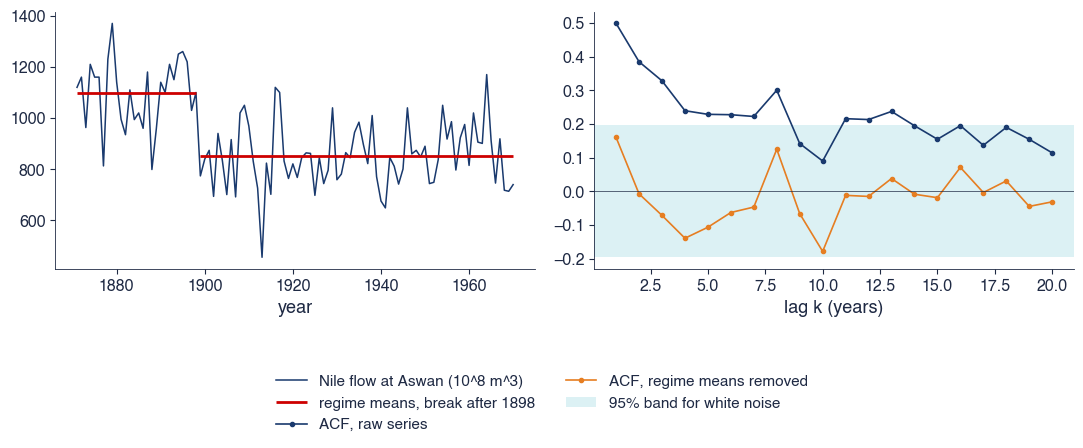

           raw     adj
r1       0.498   0.160
r10      0.090  -0.179
H        0.783   0.633
gph      0.435  -0.067
gph_se   0.147   0.147
lw       0.403  -0.168
lw_se    0.115   0.115
m       19.000  19.000
ml       0.364   0.047
ml_se    0.069   0.102


In [13]:
# Solution
b1 = b1_nile(save_it=False)
print(pd.DataFrame({k: b1[k] for k in ('raw', 'adj')}).round(3))

**Interpretation of the result.** Raw: $d \approx 0.36$–$0.44$; with the regime means removed: $d \approx 0$. For 1871–1970 the evidence of long memory comes from the 1898 break.

## B2 [Proposed]: long memory in Romanian inflation

**Question.** How persistent is Romanian inflation, and does the way we measure it change the answer? Model: B1.

1. Estimate $d$ of the monthly SA rate (`ro_inflation()`) by GPH and local Whittle with $m = \lfloor T^a\rfloor$, $a = 0.5, 0.65, 0.8$.
2. Fit ARFIMA$(0,d,0)$ and ARMA(1,1) by exact ML and compare their BIC.
3. Estimate $d$ of the 12-month rate (`ro_inflation12()`) and compare the two ACFs.
4. Interpretation: why does the 12-month rate give $d$ close to 1?

**Report:** six estimates, two BIC values, one $d$, two sentences.

In [14]:
# Your code here


## B3 [Solved]: memory in S&P 500 volatility

**Question.** Where is the memory of stock returns: in the returns or in their size?

1. Estimate $d$ of $r_t$ and $|r_t|$ by local Whittle and GPH.
2. Shuffle the days at random and re-estimate $d$ of $|r_t|$; plot both ACFs.
3. Estimate $d$ of the monthly log realised volatility.
4. Interpretation: what does the shuffle test show?

**Report:** eight estimates, the chart and one sentence.

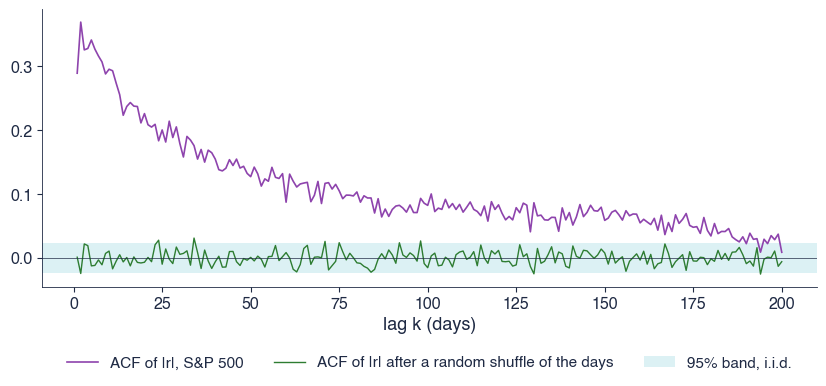

{'r': {'lw': -0.01341914570150748, 'lw_se': 0.02853650727676748, 'gph': 0.020365761457012112, 'gph_se': 0.03659949256123093}, 'abs': {'lw': 0.5305894296452771, 'lw_se': 0.02853650727676748, 'gph': 0.5561014645214712, 'gph_se': 0.03659949256123093}, 'shuf': {'lw': -0.02976035229135919, 'lw_se': 0.02853650727676748, 'gph': -0.028818803279208157, 'gph_se': 0.03659949256123093}, 'rv': {'lw': 0.4069449865374172, 'lw_se': 0.07715167498104596, 'gph': 0.3733465607607188, 'gph_se': 0.09895086764364382}}


In [15]:
# Solution
b3 = b3_sp500(save_it=False)
print({k: b3[k] for k in ('r', 'abs', 'shuf', 'rv')})

**Interpretation of the result.** $d \approx 0$ for $r_t$, about 0.53 for $|r_t|$ and 0 after the shuffle: the memory is in the order of calm and turbulent days, not in the distribution.

## B4 [Proposed]: BET and EUR/RON

**Question.** Do the BET and the EUR/RON rate show the same memory, and is it stable before and after 2008? Model: B3.

1. Estimate $d$ of $r_t$ and $|r_t|$ by local Whittle on the full sample.
2. Repeat on the subsamples up to 2007 and 2010–2026.
3. Compare the estimates for $r_t$ with the 95% Monte Carlo band of i.i.d. series of 1900 days.
4. Interpretation: is the full-sample memory of BET returns real?

**Report:** twelve estimates, one band and two sentences.

In [16]:
# Your code here


# Part C: open questions and AI critique

## C1 [Proposed]: US inflation and monetary regimes

**Question.** Is the long memory of US inflation a property of inflation or of the changes in monetary policy? Models: B1, B2.

1. Estimate $d$ by local Whittle on the full sample and in 1947–1984, 1985–2019, 2020–2026.
2. Remove the three regime means and re-estimate $d$.
3. Propose one more check.
4. Interpretation: can a constant $d$ describe 80 years of inflation?

**Report:** five estimates, one check and a project plan.

In [17]:
# Your code here


## C2 [Proposed]: audit an AI answer

**Context.** An AI assistant answered:

- (a) monthly inflation has d = 0.31, so H = d - 0.5 < 0: anti-persistent;
- (b) the 12-month rate gives d = 1.00, so Romanian inflation has a unit root;
- (c) with d = 0.31 the series is stationary and its shocks die out;
- (d) use `ARIMA(x, order=(0, 0.31, 0))` from statsmodels to fit ARFIMA;
- (e) S&P 500 returns have d = -0.01 and |r| has d = 0.53, so returns are predictable;
- (f) a significant GPH estimate proves long memory.

1. For each statement, say whether it is correct; if not, give the correct statement and the correct number.

**Report:** six verdicts with one line of justification each.

In [18]:
# Your code here
